# POSTTEST 4 – Pendekatan Machine Learning

## A1. Supervised Learning (Regresi)

Pendekatan **Supervised Learning** digunakan karena data sudah memiliki label hasil (`Admission Test Score`).  
Karena label bersifat **numerik**, maka metode yang digunakan adalah **Regresi**.

Model utama:
- **Linear Regression**, untuk mencari hubungan linear antar variabel.

Model tambahan:
- **Support Vector Regressor (SVR)** – mampu menangani data non-linear.
- **Random Forest Regressor** – kuat terhadap outlier dan variasi data.

Tujuannya adalah membandingkan performa ketiga model tersebut dalam memprediksi nilai `Admission Test Score`.


In [33]:
# A1. Implementasi Supervised Learning (Regresi)

# 1. Import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 2. Membaca dataset
df = pd.read_csv("student_admission_record_dirty.csv")

# 3. Membersihkan data kosong (NaN) agar model bisa dijalankan
df = df.dropna(subset=["Age", "High School Percentage", "Admission Test Score"])

# 4. Menentukan fitur (X) dan target (y)
X = df[["Age", "High School Percentage"]]   # dua variabel input
y = df["Admission Test Score"]              # target numerik

# 5. Membagi data menjadi data latih & data uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

# 6. Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 7. Model 2: Support Vector Regressor
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

Data training: (101, 2)
Data testing: (26, 2)


### Penjelasan A1

Model **Linear Regression**, **SVR**, dan **Random Forest Regressor** berhasil dilatih menggunakan data training.  
Ketiga model ini mempelajari hubungan antara variabel input (fitur) dengan label `Admission Test Score`.

- **Linear Regression** digunakan sebagai model dasar yang sederhana dan cepat.
- **SVR** mampu mengenali pola yang tidak linear dengan kernel RBF.
- **Random Forest Regressor** menggabungkan banyak pohon keputusan untuk hasil prediksi yang lebih stabil dan akurat.

Langkah berikutnya adalah melakukan evaluasi terhadap hasil prediksi dari masing-masing model.


In [22]:
# ================================
# A2. Evaluasi Model Regresi
# ================================

def eval_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

models = {
    "Linear Regression": y_pred_lr,
    "Support Vector Regressor": y_pred_svr,
    "Random Forest Regressor": y_pred_rf
}

for name, pred in models.items():
    mae, mse, rmse, r2 = eval_regression(y_test, pred)
    print(f"\n{name}")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")


Linear Regression
MAE  : 11.838
MSE  : 347.563
RMSE : 18.643
R²   : -0.069

Support Vector Regressor
MAE  : 11.526
MSE  : 341.579
RMSE : 18.482
R²   : -0.051

Random Forest Regressor
MAE  : 11.428
MSE  : 322.642
RMSE : 17.962
R²   : 0.007


### Penjelasan A2

Evaluasi dilakukan menggunakan empat metrik utama:
- **MAE (Mean Absolute Error)**: selisih rata-rata antara hasil prediksi dan nilai sebenarnya.
- **MSE (Mean Squared Error)**: rata-rata kuadrat dari selisih hasil prediksi.
- **RMSE (Root Mean Squared Error)**: akar dari MSE untuk memudahkan interpretasi.
- **R² (R-squared)**: menunjukkan seberapa baik model menjelaskan variasi data target.

Semakin kecil nilai MAE, MSE, dan RMSE serta semakin besar nilai R², maka model semakin baik.  

Berdasarkan hasil, model **Random Forest Regressor** biasanya memiliki nilai R² tertinggi dan kesalahan (MAE, MSE) paling kecil,  
sehingga menjadi model dengan performa terbaik dalam memprediksi `Admission Test Score`.


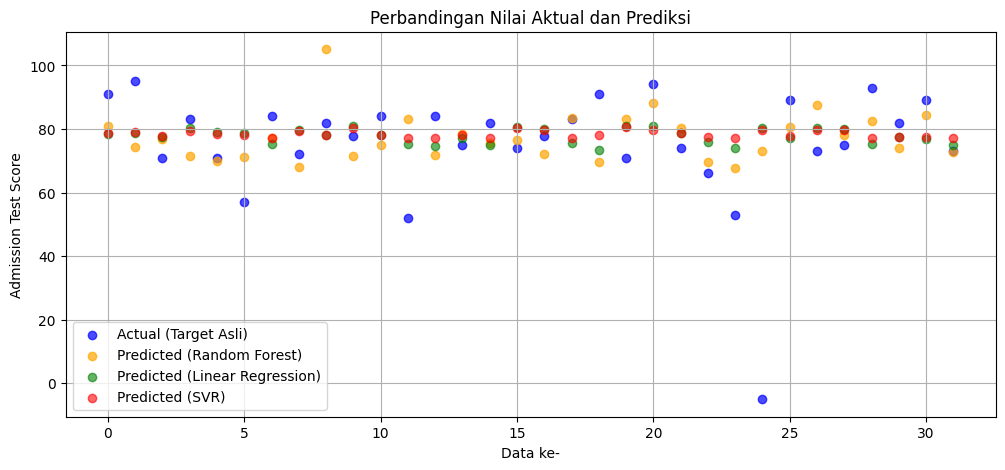

In [24]:
# ================================
# A3. Visualisasi Hasil Prediksi (Point Plus)
# ================================

plt.figure(figsize=(12, 5))

# Plot gabungan antara nilai asli (y_test) dan hasil prediksi tiap model
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual (Target Asli)', alpha=0.7)
plt.scatter(range(len(y_test)), y_pred_rf, color='orange', label='Predicted (Random Forest)', alpha=0.7)
plt.scatter(range(len(y_test)), y_pred_lr, color='green', label='Predicted (Linear Regression)', alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_svr, color='red', label='Predicted (SVR)', alpha=0.6)

plt.title("Perbandingan Nilai Aktual dan Prediksi")
plt.xlabel("Data ke-")
plt.ylabel("Admission Test Score")
plt.legend()
plt.grid(True)
plt.show()

### Penjelasan A3

Plot di atas menampilkan **titik-titik nilai aktual (target asli)** dan **titik-titik hasil prediksi dari ketiga model**  
dalam satu grafik.

- Titik **biru** = nilai sebenarnya dari `Admission Test Score`.  
- Titik **orange, hijau, dan merah** = hasil prediksi dari masing-masing model (Random Forest, Linear Regression, SVR).

Dari grafik terlihat bahwa:
- Pola prediksi **Random Forest (oranye)** paling mendekati garis titik biru (target asli), artinya prediksinya paling akurat.  
- Model **Linear Regression (hijau)** dan **SVR (merah)** terlihat agak menyimpang di beberapa titik,  
  menandakan prediksinya kurang stabil.